In [1]:
%reload_ext autoreload
%autoreload 2
import numpy as np
import os
import torch
import pandas as pd
import sys
import matplotlib.pyplot as plt
import scipy
from pyproj import Transformer
from scipy.interpolate import griddata
sys.path.append('../')
from src.plotting import Plotting
from src.utilities import load_ase_datasets, reverse_standardize
from src.ice import attenu_rate_to_temperature

aux_data = load_ase_datasets()
xs_ase, ys_ase = aux_data['coords']['xs'], aux_data['coords']['ys']
print("Keys of the auxiliary data dictionary:", aux_data.keys())

  [load_ase_datasets] Loading reference coordinates …
  [load_ase_datasets] Loading Bedmap3 …
  [load_ase_datasets] Computing Tpmp …
  [load_ase_datasets] Computing surface slope …
  [load_ase_datasets] Loading velocity …
  [load_ase_datasets] Loading domain mask …
  [load_ase_datasets] Loading surface mass balance (SMB) …
  [load_ase_datasets] All datasets ready.
Keys of the auxiliary data dictionary: dict_keys(['coords', 'sdem', 'bed', 'H', 'Tpmp', 'slope_x', 'slope_y', 'slope_mag', 'vx', 'vy', 'vel', 'mask', 'domain_bound_line', 'smb'])


In [2]:
# load the calibrated depth-averaged attenuation rate
calibrated_folder = "../data/final-obs-evidence/"
data_path       = os.getenv('RAW_DATA_PATH')
param_path      = os.getenv('PARAM_PATH')
Ns_mean_filename     = 'trainingAll_Ns_sim_mean_masked.mat'
Ns_std_filename      = 'trainingAll_Ns_sim_std_masked.mat'
atten_rate_filename = "atten_rate_calibrated.npz"

# load the calibrated attenuation rate and the flight mask
atten_rate = np.load(calibrated_folder + atten_rate_filename)
atten_rate_data = atten_rate['atten_rate_calibrated']
flight_mask     = atten_rate['flight_mask']

# load the parameter file for reverse standardization
preprocess_param = pd.read_csv(param_path, index_col=0)
Ns_standardize_epsilon = preprocess_param['Ns_standardization_epsilon'].values[0]
print("Ns_standardize_epsilon:", Ns_standardize_epsilon)

# load the standardization parameters for the training data
Ns_mean_data = scipy.io.loadmat(data_path + Ns_mean_filename)
Ns_std_data  = scipy.io.loadmat(data_path + Ns_std_filename)
Ns_mean = Ns_mean_data['Ns_mean_masked']
Ns_std = Ns_std_data['Ns_std_masked']  

# chemistry: this comes from matching the median of simulated and observed attenuation rate (processTrainingData.m)
Hp = 5.928571e-07 

# bring attenuation rate back to the physical dimension
atten_rate_physical = reverse_standardize(atten_rate_data.ravel(), Ns_mean.ravel(), Ns_std.ravel(),
                                          method='relaxation', 
                                          epsilon=Ns_standardize_epsilon)
# mask again
atten_rate_physical[~flight_mask.ravel()] = np.nan
atten_rate_physical = np.maximum(atten_rate_physical, 0.5)
calibrated_temp = attenu_rate_to_temperature(atten_rate_physical, molar_Hp = Hp).reshape(256, 256)

Ns_standardize_epsilon: 0.262291780650704


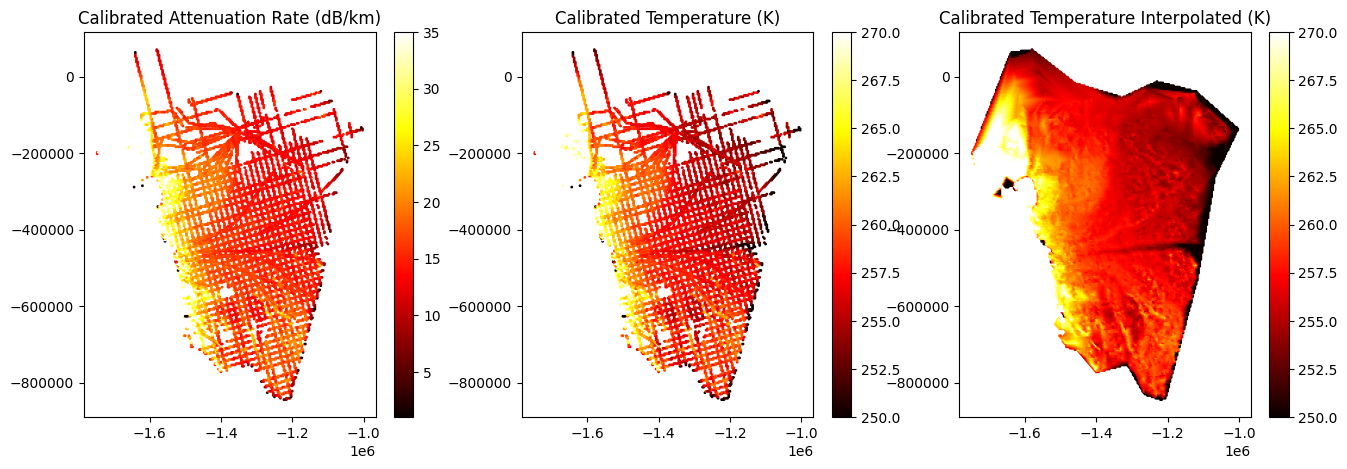

In [3]:
X, Y = np.meshgrid(xs_ase, ys_ase)
X_flight = X[flight_mask]
Y_flight = Y[flight_mask]
# interpolate
calibrated_temp_interp = griddata((X_flight.ravel(), Y_flight.ravel()), 
                                  calibrated_temp[flight_mask], 
                                  (X, Y), method='linear')

calibrated_temp_interp[aux_data['mask'] == 0] = np.nan

plt.figure(figsize=(16, 5))
plt.subplot(1,3,1)
plt.scatter(X.ravel(), Y.ravel(), c=atten_rate_physical, s=1, cmap='hot',vmin=1,vmax=35)
plt.title("Calibrated Attenuation Rate (dB/km)")
plt.colorbar()
plt.subplot(1,3,2)
plt.scatter(X.ravel(), Y.ravel(), c=calibrated_temp, s=1, cmap='hot',vmin=250,vmax=270)
plt.title("Calibrated Temperature (K)")
plt.colorbar()
plt.subplot(1,3,3)
plt.scatter(X.ravel(), Y.ravel(), c=calibrated_temp_interp, s=1, cmap='hot',vmin=250,vmax=270)
plt.title("Calibrated Temperature Interpolated (K)")
plt.colorbar()

In [ ]:
from scipy.ndimage import gaussian_filter
from src.ice import shallow_ice
from src.utilities import smooth_variable_gaussian

H = aux_data['H']                    # shape (256, 256)
alpha = aux_data['slope_mag']
sigma_field = 10.0 * H      

# ── Usage ────────────────────────────────────────────────────────────────────
H_smooth     = smooth_variable_gaussian(H, sigma_field_m=10.0 * H,
                                    xs=xs_ase, ys=ys_ase)
alpha_smooth = smooth_variable_gaussian(alpha, sigma_field_m=10.0 * H,
                                        xs=xs_ase, ys=ys_ase)


# compute the surface velocity with Shallow ice
surf_vel_sia = shallow_ice(H_smooth, alpha_smooth, calibrated_temp_interp, E = 4)


Pixel size: 3482.5 units | sigma range: 0.0 – 12.0 px
Pixel size: 3482.5 units | sigma range: 0.0 – 12.0 px


/tmp/ipykernel_3029047/4239399295.py:56: RuntimeWarning: invalid value encountered in divide
  return np.where(valid & (den > 0), num / den, np.nan)


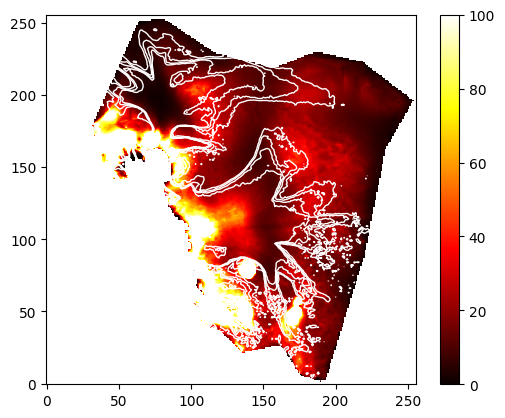

In [22]:
secinyear = 365.25 * 24 * 3600
plt.imshow(surf_vel_sia * secinyear, cmap='hot', vmin=0, vmax=100)
plt.gca().invert_yaxis()
plt.colorbar()
# add obs. surface velocity as contour, aux_data['vel']
plt.contour(aux_data['vel'], levels=np.arange(0, 100, 20), colors='white', linewidths=1)
